In [2]:
import pandas as pd
from google.colab import files


In [3]:
uploaded = files.upload()


Saving marketing_campaign.xlsx to marketing_campaign.xlsx


In [4]:
df = pd.read_excel('marketing_campaign.xlsx')
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,0,0,0,0,0,0,3,11,0


In [5]:
df.shape

(2240, 29)

In [6]:
df.isnull().sum()

,0
ID,0
Year_Birth,0
Education,0
Marital_Status,0
Income,24
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0


In [7]:
df['Income'].fillna(df['Income'].median(), inplace=True)


/tmp/ipykernel_2481/2154417476.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Income'].fillna(df['Income'].median(), inplace=True)


In [8]:
df.isnull().sum()


,0
ID,0
Year_Birth,0
Education,0
Marital_Status,0
Income,0
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0


In [10]:
df['Total_Spending'] = (
      df['MntWines'] +
          df['MntFruits'] +
              df['MntMeatProducts'] +
                  df['MntFishProducts'] +
                      df['MntSweetProducts'] +
                          df['MntGoldProds']
                          )


In [11]:
df[['Total_Spending']].head()

,Total_Spending
0,1617
1,27
2,776
3,53
4,422


In [15]:
print("Total Customers:", len(df))
print("Average Income:", round(df['Income'].mean(), 2))
print("Average Spending:", round(df['Total_Spending'].mean(), 2))

Total Customers: 2240
Average Income: 52237.98
Average Spending: 605.8


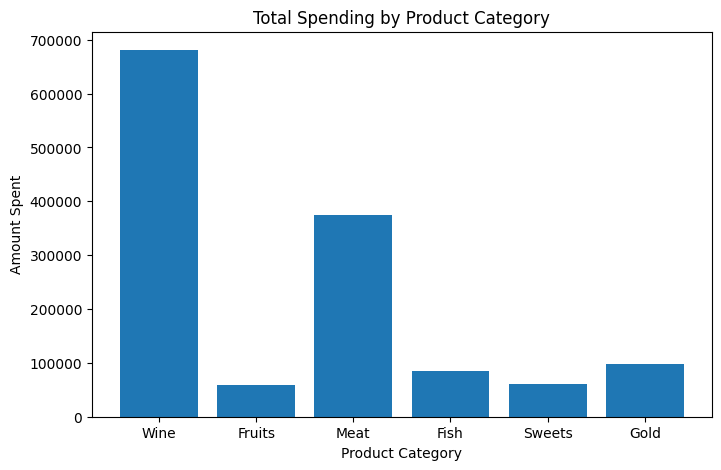

In [19]:
import matplotlib.pyplot as plt

products = ['Wine', 'Fruits', 'Meat', 'Fish', 'Sweets', 'Gold']
values = [
    df['MntWines'].sum(),
        df['MntFruits'].sum(),
            df['MntMeatProducts'].sum(),
                df['MntFishProducts'].sum(),
                    df['MntSweetProducts'].sum(),
                        df['MntGoldProds'].sum()
                        ]

plt.figure(figsize=(8,5))
plt.bar(products, values)
plt.title('Total Spending by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Amount Spent')
plt.show()

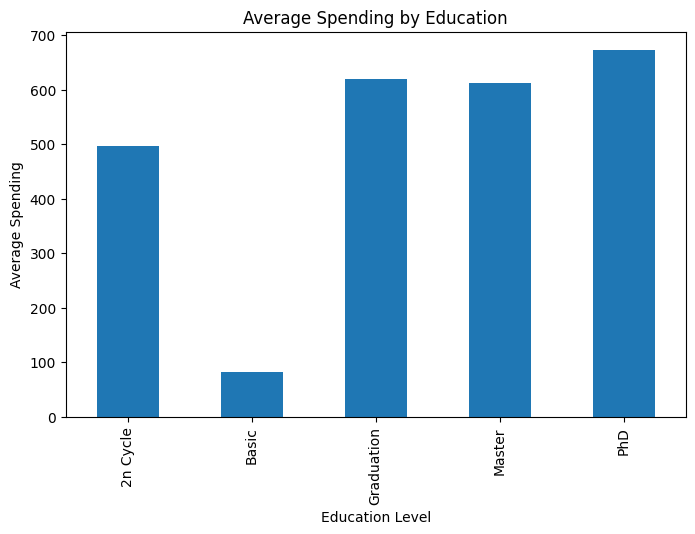

In [20]:
education_spending = df.groupby('Education')['Total_Spending'].mean()

import matplotlib.pyplot as plt

education_spending.plot(kind='bar', figsize=(8,5))

plt.title('Average Spending by Education')
plt.xlabel('Education Level')
plt.ylabel('Average Spending')
plt.show()

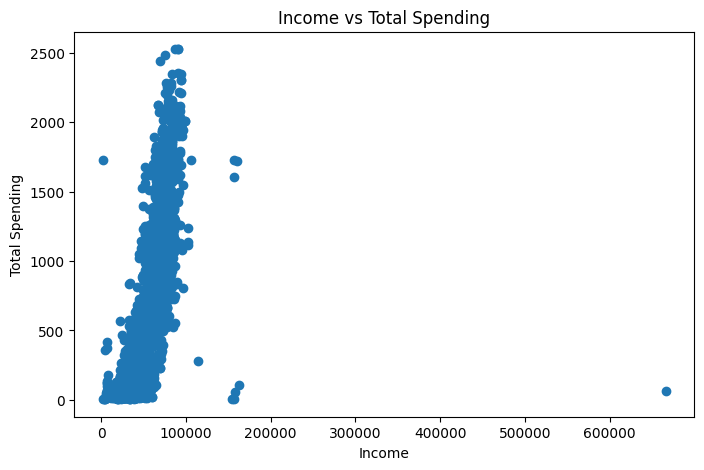

In [21]:
plt.figure(figsize=(8,5))
plt.scatter(df['Income'], df['Total_Spending'])

plt.title('Income vs Total Spending')
plt.xlabel('Income')
plt.ylabel('Total Spending')

plt.show()

In [22]:
print("Total Customers:", len(df))
print("Average Income:", round(df['Income'].mean(), 2))
print("Average Spending:", round(df['Total_Spending'].mean(), 2))

Total Customers: 2240
Average Income: 52237.98
Average Spending: 605.8


# Business Insights Report

## Overview

This project analyzes customer demographics, income levels, and purchasing behavior using a marketing campaign dataset containing 2,240 customer records.

## Key Findings

1. Product spending analysis showed that certain product categories generate significantly higher customer spending than others.

2. Education-based analysis revealed differences in spending patterns across education groups, indicating that customer background influences purchasing behavior.

3. The Income vs Total Spending analysis showed a positive relationship between income and spending. Customers with higher incomes generally spend more on products.

4. Missing values in the Income column were identified and successfully handled using median imputation, ensuring data quality for analysis.

## Recommendations

1. Focus marketing efforts on higher-income customer segments, as they contribute more to overall spending.

2. Allocate additional promotional resources to the highest-performing product categories to maximize revenue.

3. Develop targeted campaigns for customer groups with strong spending behavior identified through education-level analysis.

4. Use personalized marketing strategies to improve customer engagement and increase purchase frequency.

## Conclusion

The analysis indicates that customer income and demographic characteristics strongly influence purchasing behavior. Businesses can improve marketing effectiveness by targeting high-value customer segments and investing more in top-performing product categories.
